# Convergence analysis using different number of paths - Experiments on one agent using PettingZoo

In this notebook there is one agent in the system that decides randomly one origin and destination and learns the best roote. In this scenario there are 3 different paths to choose from. The PPO algorithm is implemented to learn.

### 3 paths to choose from

In [2]:
from environment import TrafficEnvironment
from keychain import Keychain as kc
import os
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3 import PPO
import supersuit as ss
from Sumo_controller import Sumo

from utilities import confirm_env_variable
from utilities import get_params
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [3]:
confirm_env_variable(kc.SUMO_HOME, append="tools")
params = get_params(kc.PARAMS_PATH)

[CONFIRMED] Environment variable exists: SUMO_HOME
[SUCCESS] Added module directory: C:\Program Files (x86)\Eclipse\Sumo\tools


In [4]:
Sumo_sim=Sumo(params)
Sumo_sim.Sumo_start()

In [4]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])

[SUCCESS] Generated & saved 12 paths to: paths.csv
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [5.617165975566803, 45.08917067806191, 109.42695563466584], (0, 1): [51.03261476439725, 139.03180179671705, 375.1153910024779], (1, 0): [43.93199829112916, 4.59822842086661, 13.62798048647607], (1, 1): [1254.5593759588041, 2719.8132149004878, 87.82011083088526]}
[SUCCESS] Free flow times calculated!
[SUCCESS]: The vehicle will travel from origin  [1]  to destination. [0]  This path has free flow travel time:  [43.93199829112916, 4.59822842086661, 13.62798048647607]


In [5]:
env.reset()
env.reward_table = []

In [6]:
env = ss.pettingzoo_env_to_vec_env_v1(env)
env = ss.concat_vec_envs_v1(env, 1, num_cpus=2, base_class="stable_baselines3")

In [7]:
tuned_params = {
        "gamma": 0.9,
        "learning_rate": 1e-3,
    }

model = PPO(
    "MlpPolicy",
    env,
    verbose = 0,
    n_steps = 10,
    batch_size=10,
    **tuned_params
)

In [8]:
model.learn(total_timesteps=1000)

Reward table is:  [-56.61666666666667, -16.55, -56.61666666666667, -56.61666666666667, -16.55, -5.8, -56.61666666666667, -56.61666666666667, -16.55, -16.55, -16.55, -56.61666666666667, -16.55, -16.55, -16.55, -5.8, -5.8, -5.8, -16.55, -56.61666666666667, -16.55, -5.8, -16.55, -56.61666666666667, -5.8, -16.55, -5.8, -5.8, -16.55, -16.55, -16.55, -5.8, -16.55, -5.8, -16.55, -5.8, -16.55, -16.55, -16.55, -5.8, -56.61666666666667, -5.8, -16.55, -5.8, -5.8, -56.61666666666667, -56.61666666666667, -56.61666666666667, -5.8, -5.8, -5.8, -16.55, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -16.55, -5.8, -5.8, -5.8, -5.8, -16.55, -56.61666666666667, -5.8, -16.55, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -56.61666666666667, -5.8, -56.61666666666667, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -16.55, -5.8, -5.8, -5.8,

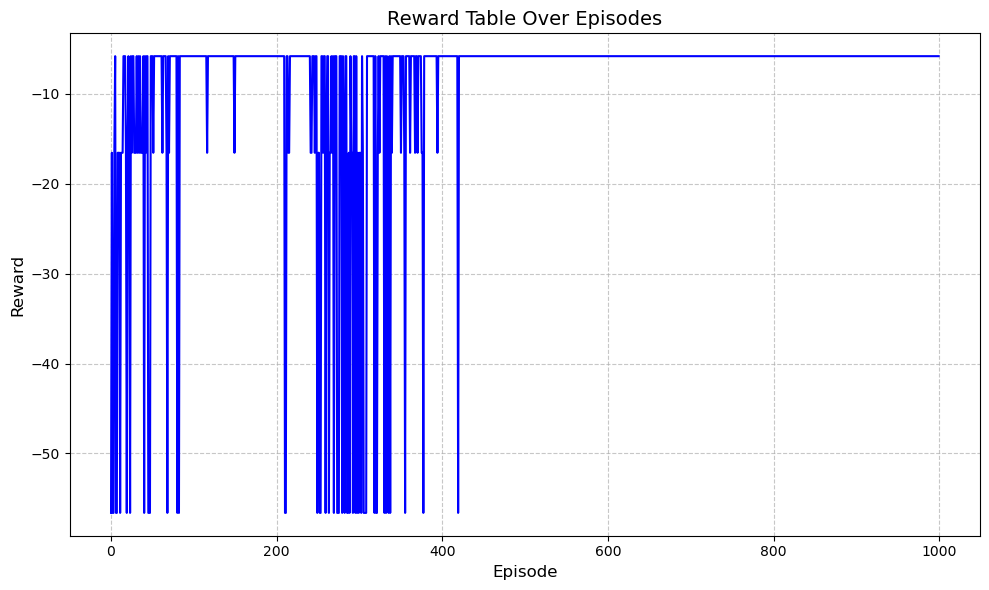

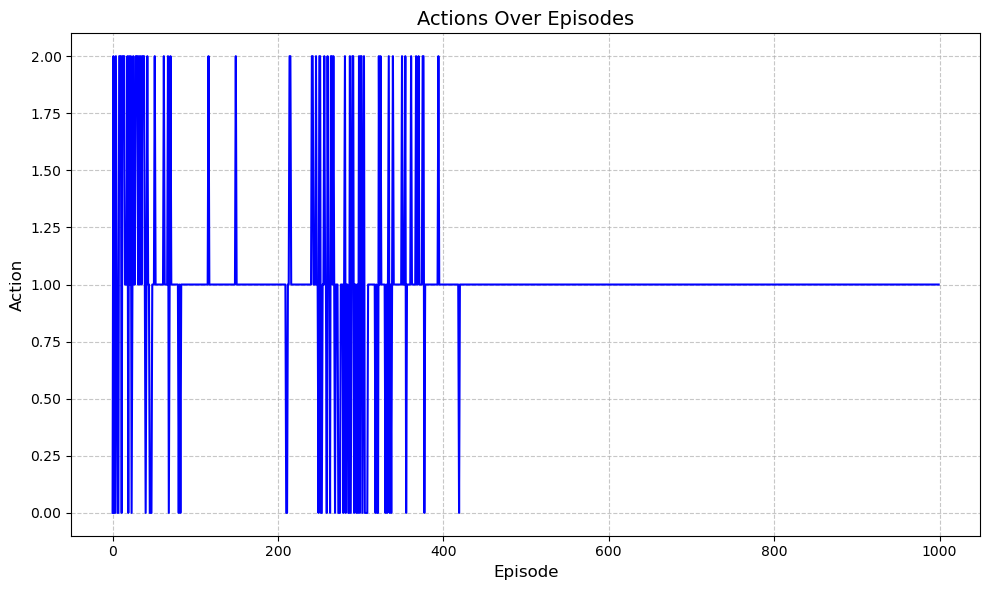

In [9]:
env.close()

### 5 paths to choose from

In [5]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])

[SUCCESS] Generated & saved 20 paths to: paths.csv
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [162.87580656635438, 598.718440408218, 713.0715100453367, 86.5905014928801, 17.963641438246924], (0, 1): [265.39638385497364, 1176.9047102220861, 83.60206537319144, 383.15546251815726, 109.2051031681003], (1, 0): [8.492466017673049, 221.42365243005784, 103.23512683831197, 169.89763109921427, 18.666140263952883], (1, 1): [1523.1951203106307, 25.115737425279697, 188.1253528713247, 2159.7237614655014, 47.50153765198908]}
[SUCCESS] Free flow times calculated!
[SUCCESS]: The vehicle will travel from origin  [0]  to destination. [1]  This path has free flow travel time:  [265.39638385497364, 1176.9047102220861, 83.60206537319144, 383.15546251815726, 109.2051031681003]


In [6]:
env.reset()
env.reward_table = []

In [7]:
env = ss.pettingzoo_env_to_vec_env_v1(env)
env = ss.concat_vec_envs_v1(env, 1, num_cpus=2, base_class="stable_baselines3")

In [8]:
tuned_params = {
        "gamma": 0.9,
        "learning_rate": 1e-3,
    }

model = PPO(
    "MlpPolicy",
    env,
    verbose = 1,
    n_steps = 10,
    batch_size=10,
    **tuned_params
)

Using cpu device


In [9]:
model.learn(total_timesteps=3000)

----------------------------
| time/              |     |
|    fps             | 0   |
|    iterations      | 1   |
|    time_elapsed    | 140 |
|    total_timesteps | 10  |
----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 0            |
|    iterations           | 2            |
|    time_elapsed         | 313          |
|    total_timesteps      | 20           |
| train/                  |              |
|    approx_kl            | 0.0006976366 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.1         |
|    explained_variance   | -6.04e-05    |
|    learning_rate        | 0.001        |
|    loss                 | 3.55e+05     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0155      |
|    value_loss           | 7.1e+05      |
------------------------------------------
-----------------------

Traceback (most recent call last):
  File "c:\Users\Anastasia\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py", line 3526, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\Anastasia\AppData\Local\Temp\ipykernel_9512\3226838610.py", line 1, in <module>
    model.learn(total_timesteps=3000)
  File "c:\Users\Anastasia\anaconda3\Lib\site-packages\stable_baselines3\ppo\ppo.py", line 315, in learn
    return super().learn(
           ^^^^^^^^^^^^^^
  File "c:\Users\Anastasia\anaconda3\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py", line 277, in learn
    continue_training = self.collect_rollouts(self.env, callback, self.rollout_buffer, n_rollout_steps=self.n_steps)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Anastasia\anaconda3\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py", line 194, in collect_rollouts
    new_obs, 

Reward table is:  [-41.666666666666664, -51.13333333333333, -41.666666666666664, -51.13333333333333, -41.666666666666664, -51.13333333333333, -51.13333333333333, -41.666666666666664, -51.13333333333333, -41.666666666666664, -51.13333333333333, -41.666666666666664, -20.316666666666666, -20.316666666666666, -20.316666666666666, -41.666666666666664, -20.316666666666666, -20.316666666666666, -20.316666666666666, -41.666666666666664, -20.316666666666666, -41.666666666666664, -41.666666666666664, -41.666666666666664, -41.666666666666664, -41.666666666666664, -20.316666666666666, -41.666666666666664, -51.13333333333333, -51.13333333333333, -51.13333333333333, -20.316666666666666, -41.666666666666664, -20.316666666666666, -20.316666666666666, -41.666666666666664, -41.666666666666664, -20.316666666666666, -41.666666666666664, -41.666666666666664, -20.316666666666666, -20.316666666666666, -41.666666666666664, -51.13333333333333, -51.13333333333333, -41.666666666666664, -20.316666666666666, -51.1

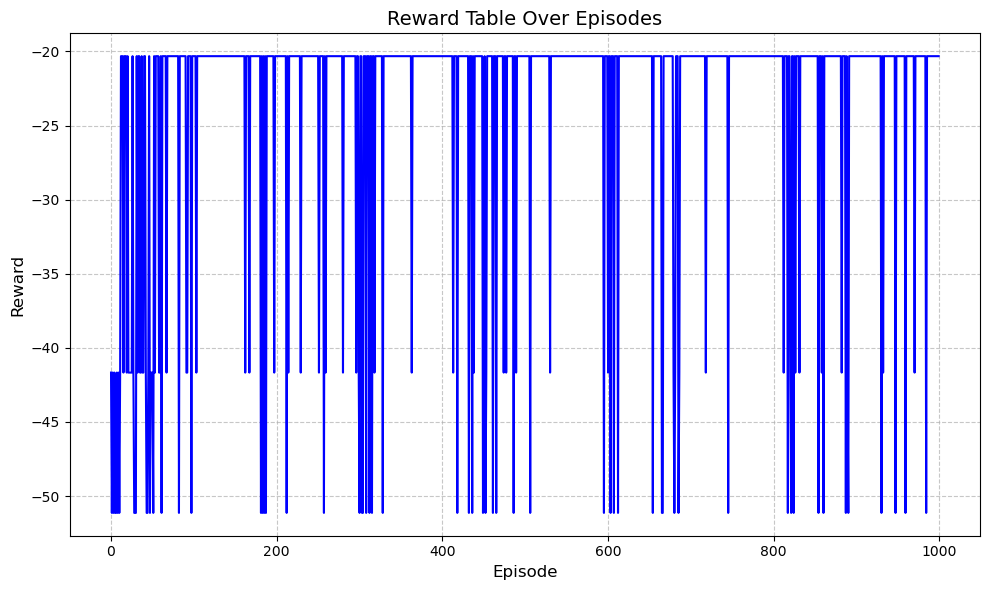

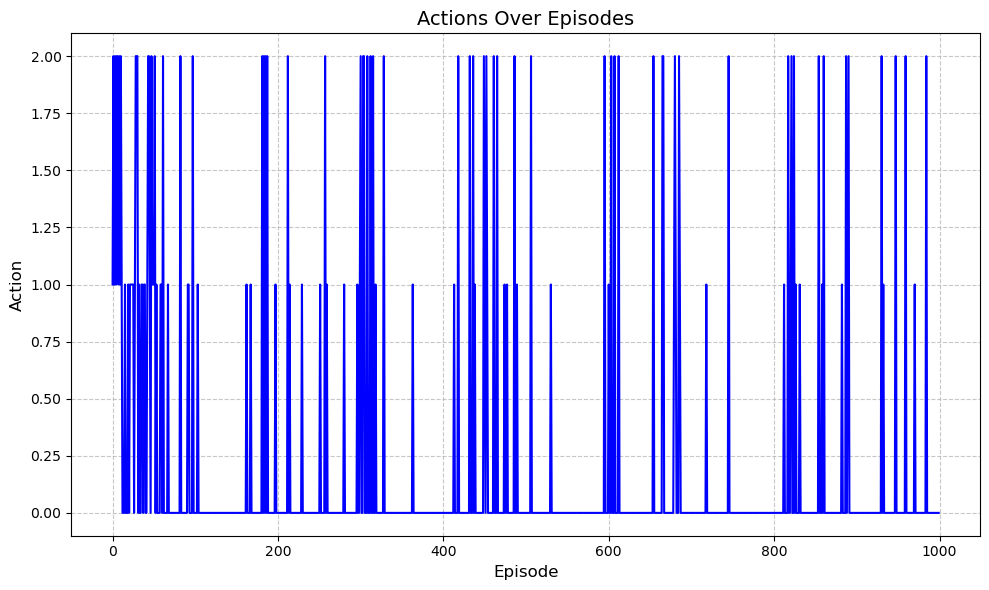

In [ ]:
env.close()